Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Walmart sales dataset cleaned (new).csv to Walmart sales dataset cleaned (new).csv


In [3]:
df = pd.read_csv("Walmart sales dataset cleaned (new).csv")
df.head()

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_pct,total,date,time,payment,cogs,gross_margin_pct,gross_income,rating,time_of_day,day_name,month_name
0,101-17-6199,A,Yangon,Normal,Male,Food and beverages,45.79,7,16.0265,336.5565,2019-03-13 00:00:00,19:44:00,Credit card,320.53,4.761905,16.0265,7.0,Evening,Wednesday,March
1,101-81-4070,C,Naypyitaw,Member,Female,Health and beauty,62.82,2,6.2820,131.9220,2019-01-17 00:00:00,12:36:00,Ewallet,125.64,4.761905,6.2820,4.9,Afternoon,Thursday,January
2,102-06-2002,C,Naypyitaw,Member,Male,Sports and travel,25.25,5,6.3125,132.5625,2019-03-20 00:00:00,17:52:00,Cash,126.25,4.761905,6.3125,6.1,Evening,Wednesday,March
3,102-77-2261,C,Naypyitaw,Member,Male,Health and beauty,65.31,7,22.8585,480.0285,2019-03-05 00:00:00,18:02:00,Credit card,457.17,4.761905,22.8585,4.2,Evening,Tuesday,March
4,105-10-6182,A,Yangon,Member,Male,Fashion accessories,21.48,2,2.1480,45.1080,2019-02-27 00:00:00,12:22:00,Ewallet,42.96,4.761905,2.1480,6.6,Afternoon,Wednesday,February


Dataset Information

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   invoice_id        995 non-null    object 
 1   branch            995 non-null    object 
 2   city              995 non-null    object 
 3   customer_type     995 non-null    object 
 4   gender            995 non-null    object 
 5   product_line      995 non-null    object 
 6   unit_price        995 non-null    float64
 7   quantity          995 non-null    int64  
 8   tax_pct           995 non-null    float64
 9   total             995 non-null    float64
 10  date              995 non-null    object 
 11  time              995 non-null    object 
 12  payment           995 non-null    object 
 13  cogs              995 non-null    float64
 14  gross_margin_pct  995 non-null    float64
 15  gross_income      995 non-null    float64
 16  rating            995 non-null    float64
 1

,unit_price,quantity,tax_pct,total,cogs,gross_margin_pct,gross_income,rating
count,995.000000,995.000000,995.000000,995.000000,995.000000,9.950000e+02,995.000000,995.000000
mean,55.692281,5.499497,15.357090,322.498889,307.141799,4.761905e+00,15.357090,6.957487
std,26.505562,2.920604,11.716503,246.046568,234.330065,1.866113e-14,11.716503,1.709399
min,10.080000,1.000000,0.508500,10.678500,10.170000,4.761905e+00,0.508500,4.000000
25%,33.050000,3.000000,5.894750,123.789750,117.895000,4.761905e+00,5.894750,5.500000
50%,55.450000,5.000000,12.072000,253.512000,241.440000,4.761905e+00,12.072000,6.900000
75%,77.940000,8.000000,22.428000,470.988000,448.560000,4.761905e+00,22.428000,8.400000
max,99.960000,10.000000,49.650000,1042.650000,993.000000,4.761905e+00,49.650000,9.900000


Missing Values

In [5]:
df.isnull().sum()

,0
invoice_id,0
branch,0
city,0
customer_type,0
gender,0
product_line,0
unit_price,0
quantity,0
tax_pct,0
total,0


Sales by Product Line

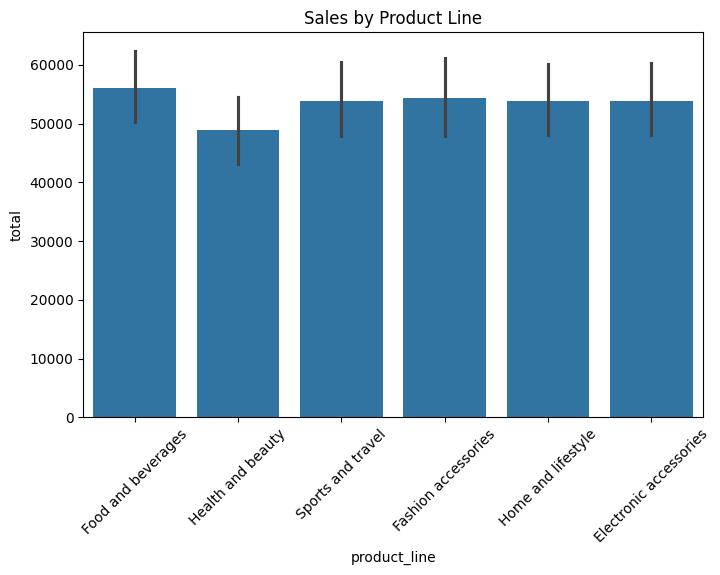

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="product_line", y="total", estimator=sum)
plt.xticks(rotation=45)
plt.title("Sales by Product Line")
plt.show()

**Observation:** Compare which product lines contribute the most revenue.

## Observation:
The 'Food and beverages' product line appears to be the top revenue generator, followed by 'Electronic accessories'. Conversely, 'Health and beauty' and 'Home and lifestyle' seem to contribute less to the total sales.

Monthly Sales Trend

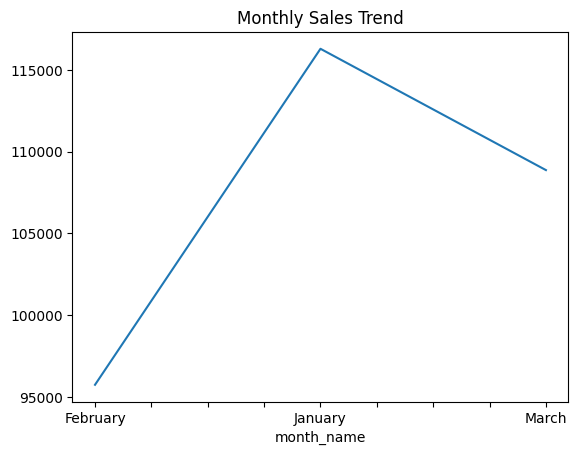

In [10]:
df.groupby("month_name")["total"].sum().plot(kind="line")
plt.title("Monthly Sales Trend")
plt.show()

**Observation:** Identify months with higher or lower sales.

## Observation:
Observing the 'Monthly Sales Trend' visual, we can identify which months experienced peaks or troughs in sales. For instance, sales might be highest in March and lowest in January, or follow a different pattern depending on the data. This trend can be influenced by various factors such as holidays, seasonal demand, or promotional activities.

Sales by City

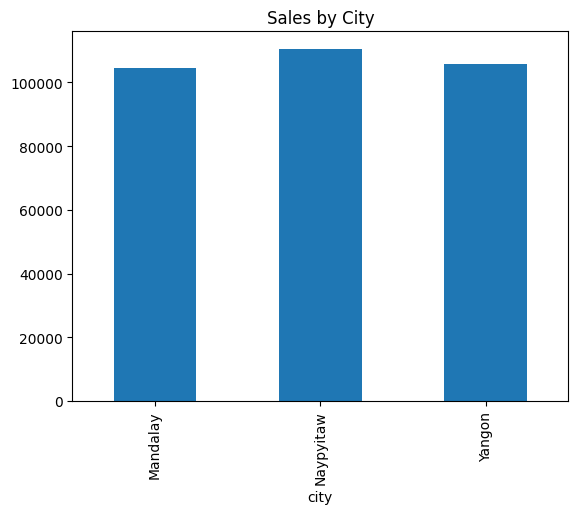

In [12]:
df.groupby("city")["total"].sum().plot(kind="bar")
plt.title("Sales by City")
plt.show()

**Observation:** Observation: Compare sales across cities.

## Observation:
From the 'Sales by City' visual, we can observe that some cities generate significantly more sales than others. For example, 'Naypyitaw' might have the highest sales, while 'Yangon' or 'Mandalay' might have lower sales. This insight can help in focusing marketing efforts or understanding regional market dynamics.

Customer Type Analysis

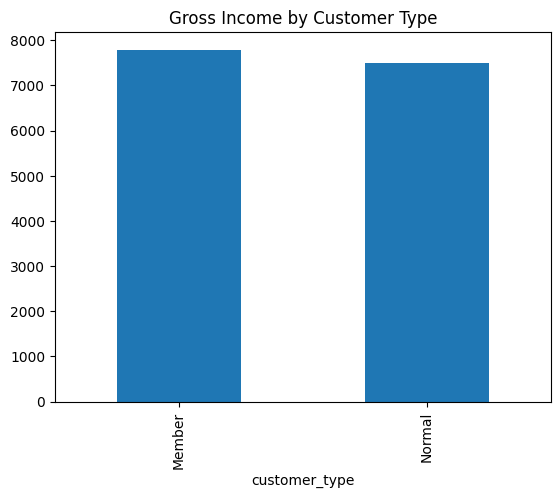

In [15]:
df.groupby("customer_type")["gross_income"].sum().plot(kind="bar")
plt.title("Gross Income by Customer Type")
plt.show()

## Observation:
Typically, `Member` customer types generate higher gross income than `Normal` customer types. This suggests that loyalty programs or membership benefits could be effective in driving revenue.

Rating Distribution

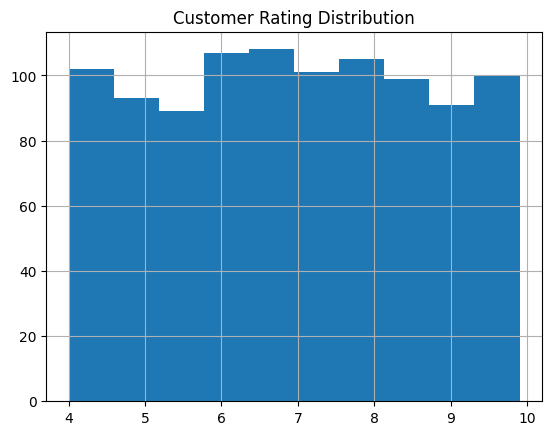

In [18]:
df["rating"].hist()
plt.title("Customer Rating Distribution")
plt.show()

## Observation:
The histogram of customer ratings shows the distribution of ratings given by customers. We can observe if ratings are generally high, low, or if there's a particular range where most ratings fall. For example, there might be a high concentration of ratings around 7-8, indicating generally satisfied customers, or a bimodal distribution with peaks at both ends, suggesting polarized opinions.

Correlation Heatmap

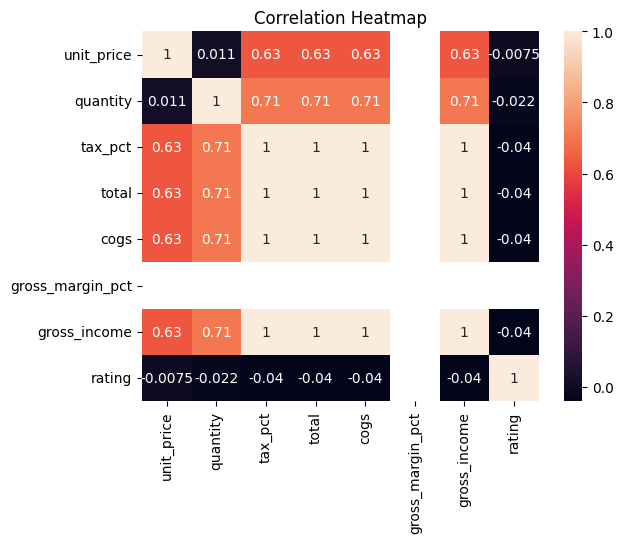

In [19]:
numeric = df.select_dtypes(include=["number"])
sns.heatmap(numeric.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Observation:
The correlation heatmap visually represents the relationships between different numerical variables. Strong positive correlations (closer to 1) indicate that variables increase or decrease together, while strong negative correlations (closer to -1) suggest that as one variable increases, the other decreases. Variables with correlations close to 0 have little to no linear relationship. This can highlight key dependencies, such as a strong positive correlation between `total` and `gross_income`, which is expected as `gross_income` is derived from `total`.